In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#carregando dados
df_vendas = pd.read_csv("retail_sales_dataset.csv")
display(df_vendas)
df_analise = df_vendas


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [97]:
#inspeção de dados
display(df_analise.info())
display(df_analise.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


None

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [98]:
#tratamento de dados

#tipos de dados
df_analise["Date"] = pd.to_datetime(df_analise["Date"])

# duplicatas
df_analise = df_analise.drop_duplicates(subset="Transaction ID")

display(df_analise)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [99]:
# categorias
display(df_analise["Product Category"].unique())


<StringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str

In [100]:

#analise
df_analise = df_analise.sort_values(by=["Date", "Total Amount"])  # Organizar por data
df_analise = df_analise.reset_index(drop=True)
display(df_analise)

df_categorias = df_analise[["Product Category", "Total Amount"]].groupby(by="Product Category", as_index=False).sum()
df_categorias = df_categorias.sort_values(by= "Product Category", ascending=False)

df_generos = df_analise[["Product Category", "Gender", "Total Amount"]].groupby(by=["Product Category", "Gender"], as_index=False).sum()
df_generos = df_generos.sort_values(by=["Product Category", "Total Amount"], ascending=[False,False])

df_top_genero = df_generos.groupby(by="Product Category", as_index=False).first()
df_top_genero = df_top_genero.sort_values(by="Total Amount", ascending=False)


display(df_categorias)
display(df_generos)
display(df_top_genero)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,180,2023-01-01,CUST180,Male,41,Clothing,3,300,900
1,559,2023-01-01,CUST559,Female,40,Clothing,4,300,1200
2,522,2023-01-01,CUST522,Male,46,Beauty,3,500,1500
3,979,2023-01-02,CUST979,Female,19,Beauty,1,25,25
4,303,2023-01-02,CUST303,Male,19,Electronics,3,30,90
...,...,...,...,...,...,...,...,...,...
995,908,2023-12-29,CUST908,Male,46,Beauty,4,300,1200
996,805,2023-12-29,CUST805,Female,30,Beauty,3,500,1500
997,857,2023-12-31,CUST857,Male,60,Electronics,2,25,50
998,650,2024-01-01,CUST650,Male,55,Electronics,1,30,30


,Product Category,Total Amount
2,Electronics,156905
1,Clothing,155580
0,Beauty,143515


,Product Category,Gender,Total Amount
5,Electronics,Male,80170
4,Electronics,Female,76735
2,Clothing,Female,81275
3,Clothing,Male,74305
0,Beauty,Female,74830
1,Beauty,Male,68685


,Product Category,Gender,Total Amount
1,Clothing,Female,81275
2,Electronics,Male,80170
0,Beauty,Female,74830


Gender,Female,Male
Product Category,,
Beauty,74830,68685
Clothing,81275,74305
Electronics,76735,80170


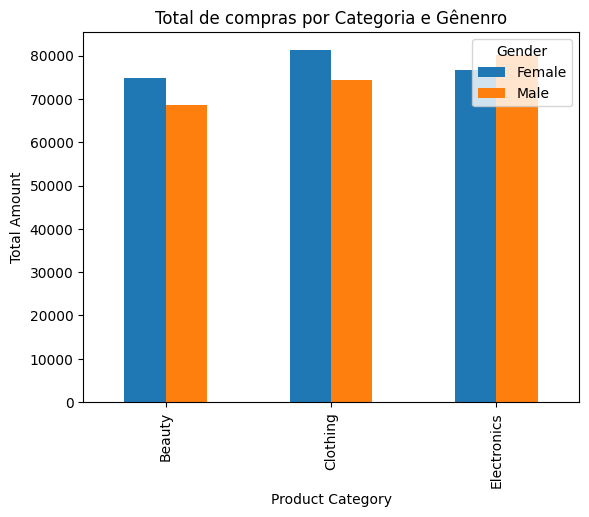

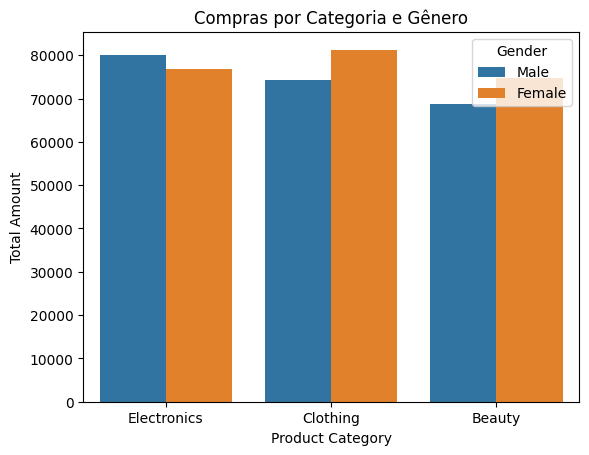

In [103]:
# gráficos
df_pivot = df_generos.pivot(
    index="Product Category",
    columns="Gender",
    values="Total Amount"
)

display(df_pivot)

df_pivot.plot(kind="bar")

plt.title("Total de compras por Categoria e Gênenro")
plt.ylabel("Total Amount")
plt.xlabel("Product Category")

plt.show()

sns.barplot(
    data=df_generos,
    x="Product Category",
    y="Total Amount",
    hue="Gender"
)

plt.title("Compras por Categoria e Gênero")

plt.show()